# the wai aria roles as data

script and style do not have corresponding roles

In [1]:
import rdflib

g = rdflib.Graph()

g.parse("https://www.w3.org/WAI/ARIA/schemata/aria-1.rdf")
from nbref import Schema, schema
from nbref.utils import el
import pandas, nbref.roles

In [2]:
Schema(type=["integer"], title="number", description="this description").expand()(2.1).set_name("number").render_html()

In [3]:
NB = Schema.from_file(schema.parent/"nb.yaml").expand()

nb = Schema.Object.from_file("Untitled1.ipynb").set_schema(NB).modify(Schema.from_string("""
properties:
    cells: 
        items:
            properties:
                source:
                    style: 
                        width: 100%
"""))
for cell in nb["cells"]:
    cell.setdefault("execution_count", -1)
    if cell["execution_count"] is None:
        cell["execution_count"] = -1
    if cell["cell_type"] == "markdown":
        cell["outputs"] = [dict(output_type="display_data", data={
            "text/markdown": cell["source"]
        })]
    # print(Schema(type=Schema.type(cell.schema)).is_valid(cell))

In [4]:
nb["cells"].render_html()

In [5]:
s = Schema(type=["integer", "string"]).expand()

In [5]:
s(0).modify(title="test").render_html()

0 {
    "type": "integer"
}
spinbutton
 {
    "type": "string"
}
textbox


In [6]:
Schema(type="string")("abc").render_html()

textbox


In [3]:
nbref.roles.render_schema(s, s(1).modify(title="number").set_name("number"), None)

<div><label for="number">number</label><input class="type" id="number" step="1" type="number" value="1"></input></div>

In [4]:
nbref.roles.render_schema(s := Schema(
    type="array", items=dict(type="integer")
), x:=s([1, 2.1]).set_name("yo"), None)

<section class="dialog"><details open="True"><summary>yo</summary><ol class="list"><li class="listitem"><label for="yo:0">1</label><input class="type" id="yo:0" step="1" type="number" value="1"></input></li><li class="listitem"><label for="yo:1">2</label><input class="type" id="yo:1" step="1" type="number" value="2.1"></input></li></ol></details></section>

In [5]:
x[1].expand().schema

{
    "type": "integer",
    "not": {
        "$schema": "http://json-schema.org/schema#",
        "type": "number"
    }
}

In [11]:
CLASS = "http://www.w3.org/2002/07/owl#Class"
SUBCLASS = "http://www.w3.org/2000/01/rdf-schema#subClassOf"
SUPPORTED = "http://www.w3.org/1999/xhtml/vocab#supportedState"

In [56]:
fragment = lambda x: x.str.rpartition("#")[2]

In [63]:
df = Schema.Array.from_string(g.serialize(format="json-ld")).pipe(pandas.DataFrame
).explode("@type").set_index(["@type"]).explode("http://www.w3.org/2000/01/rdf-schema#subClassOf")
df[SUBCLASS] = df[SUBCLASS].apply(get("@id", default=None))

df["klass"] = df["@id"].pipe(fragment)
df = df.set_index("klass", append=True)

In [124]:
states = df.loc[CLASS][SUPPORTED].dropna().explode().apply(pandas.Series)["@id"].pipe(fragment).str.partition("-")[2].rename("aria").groupby(level=0).agg(list).to_dict()

'http://www.w3.org/2002/07/owl#Class'

In [131]:
subclasses = df.loc[CLASS][SUBCLASS].pipe(fragment)
subclasses_mapping = subclasses.groupby(level=0).agg(list).to_dict()

In [133]:
subclasses_mapping

{'alert': ['section'],
 'alertdialog': ['alert', 'dialog'],
 'application': ['structure'],
 'article': ['document'],
 'banner': ['landmark'],
 'button': ['command'],
 'cell': ['section'],
 'checkbox': ['input'],
 'columnheader': ['cell', 'gridcell', 'sectionhead'],
 'combobox': ['select'],
 'command': ['widget'],
 'complementary': ['landmark'],
 'composite': ['widget'],
 'contentinfo': ['landmark'],
 'definition': ['section'],
 'dialog': ['window'],
 'directory': ['list'],
 'document': ['structure'],
 'feed': ['list'],
 'figure': ['section'],
 'form': ['landmark'],
 'grid': ['composite', 'table'],
 'gridcell': ['cell', 'widget'],
 'group': ['section'],
 'heading': ['sectionhead'],
 'img': ['section'],
 'input': ['widget'],
 'landmark': ['section'],
 'link': ['command'],
 'list': ['section'],
 'listbox': ['select'],
 'listitem': ['section'],
 'log': ['section'],
 'main': ['landmark'],
 'marquee': ['section'],
 'math': ['section'],
 'menu': ['select'],
 'menubar': ['menu'],
 'menuitem': 

In [130]:
subclasses.apply(subclasses_mapping.get)

klass
definition                              [structure]
listbox                          [composite, group]
math                                    [structure]
marquee                                 [structure]
dialog                                   [roletype]
                              ...                  
range                                    [roletype]
widget        [_:N379cafd11605455aab12ac4ed094ccd9]
menuitem                                   [widget]
region                                    [section]
section                                  [roletype]
Name: 2, Length: 99, dtype: object

In [118]:
subclasses.sort_index()

klass
alert            section
alertdialog        alert
alertdialog       dialog
application    structure
article         document
                 ...    
treegrid            grid
treeitem        listitem
treeitem          option
widget          roletype
window          roletype
Name: 2, Length: 99, dtype: str

In [116]:
pandas.concat([
    pandas.Series(subclasses.index.map(states.get), subclasses.index),
    subclasses.apply(states.get)
]).dropna().groupby(level=0).agg(lambda x: sum(x, []))

klass
alert                                                 [expanded]
application                                   [activedescendant]
article                            [posinset, setsize, expanded]
button                                       [expanded, pressed]
cell            [colindex, colspan, rowindex, rowspan, expanded]
                                     ...                        
tree           [multiselectable, required, orientation, orien...
treegrid       [level, multiselectable, readonly, level, mult...
treeitem       [level, posinset, setsize, checked, posinset, ...
widget         [atomic, busy, controls, current, describedby,...
window         [expanded, modal, atomic, busy, controls, curr...
Length: 63, dtype: object

In [21]:
properties = df.loc[CLASS][SUPPORTED].explode().dropna().apply(pandas.Series)["@id"]

In [36]:
properties = pandas.Series(
    properties.str.rpartition("#")[2].values,
    properties.index.to_series().str.rpartition("#")[2].values
).str.partition("-")[2]

In [40]:
properties.sort_index().to_frame("aria").rename_axis("role").style

,aria
role,
application,activedescendant
article,setsize
article,posinset
button,expanded
button,pressed
cell,rowindex
cell,rowspan
cell,colindex
cell,colspan


In [9]:
df

http://www.w3.org/1999/xhtml/vocab#nameFrom  \
@type                                        @id                                                                                                  
http://www.w3.org/2002/07/owl#Class          http://www.w3.org/WAI/ARIA/Schemata/aria-1#defi...                          [{'@value': 'author'}]   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#listbox                          [{'@value': 'author'}]   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#math                             [{'@value': 'author'}]   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#marquee                          [{'@value': 'author'}]   
http://www.w3.org/2002/07/owl#ObjectProperty http://www.w3.org/WAI/ARIA/Schemata/aria-1#base...                                             NaN   
...                                                                                                                                         ...   
http://www.w3.org/2002/07/owl#Class          http://www.w3.org/WAI/ARIA/Schemata/aria-1#range                            [{'@value': 'author'}]   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#widget                              [{'@value': 'n/a'}]   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#menu...  [{'@value': 'contents'}, {'@value': 'author'}]   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#region                           [{'@value': 'author'}]   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#section                             [{'@value': 'n/a'}]   

                                                                                                      http://www.w3.org/2000/01/rdf-schema#seeAlso  \
@type                                        @id                                                                                                     
http://www.w3.org/2002/07/owl#Class          http://www.w3.org/WAI/ARIA/Schemata/aria-1#defi...  [{'@id': 'https://www.w3.org/TR/html5/grouping...   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#listbox  [{'@id': 'https://www.w3.org/TR/html5/forms.ht...   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#math                                                   NaN   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#marquee                                                NaN   
http://www.w3.org/2002/07/owl#ObjectProperty http://www.w3.org/WAI/ARIA/Schemata/aria-1#base...                                                NaN   
...                                                                                                                                            ...   
http://www.w3.org/2002/07/owl#Class          http://www.w3.org/WAI/ARIA/Schemata/aria-1#range                                                  NaN   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#widget                                                 NaN   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#menu...  [{'@id': 'http://docs.oracle.com/javase/6/docs...   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#region   [{'@id': 'https://www.w3.org/TR/html5/obsolete...   
                                             http://www.w3.org/WAI/ARIA/Schemata/aria-1#section  [{'@id': 'http://www.loc.gov/nls/z3986/v100/dt...   

                                                                                                   http://www.w3.org/2000/01/rdf-schema#subClassOf  \
@type                                        @id                                       

In [102]:
import networkx

In [134]:
g = networkx.Graph()

edges = df.loc[CLASS, [SUBCLASS]].reset_index().map(
    lambda x: x.rpartition("#")[2] if isinstance(x, str) else x
)[[SUBCLASS, "@id"]]
edges.dropna(how="any", axis=0).apply(lambda x: g.add_edge(*x), axis=1);

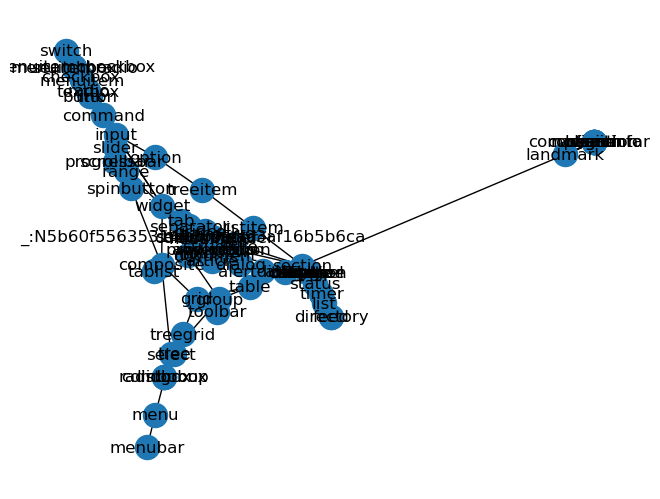

In [135]:
networkx.draw_spectral(g, with_labels=True)

In [126]:
networkx.draw_networkx_labels(g)

TypeError: draw_networkx_labels() missing 1 required positional argument: 'pos'

In [100]:
df.loc[CLASS].index.to_series().str.rpartition("#")[2].drop_duplicates().pipe(lista
                                                                             )

['cell',
 'gridcell',
 'region',
 'figure',
 'banner',
 'alert',
 'tabpanel',
 'slider',
 'treegrid',
 'separator',
 'img',
 'grid',
 'range',
 'landmark',
 'window',
 'application',
 'directory',
 'table',
 'tree',
 'searchbox',
 'timer',
 'spinbutton',
 'definition',
 'contentinfo',
 'treeitem',
 'menu',
 'dialog',
 'row',
 'widget',
 'switch',
 'complementary',
 'link',
 'heading',
 'search',
 'option',
 'list',
 'status',
 'menuitemcheckbox',
 'log',
 'listitem',
 'menuitemradio',
 'none',
 'radiogroup',
 'scrollbar',
 'group',
 'composite',
 'math',
 'input',
 'radio',
 'feed',
 'menubar',
 'rowheader',
 'note',
 'form',
 'checkbox',
 'alertdialog',
 'term',
 'listbox',
 'navigation',
 'progressbar',
 'rowgroup',
 'sectionhead',
 'combobox',
 'columnheader',
 'document',
 'article',
 'command',
 'toolbar',
 'textbox',
 'section',
 'tab',
 'structure',
 'tooltip',
 'presentation',
 'tablist',
 'main',
 'roletype',
 'button',
 'menuitem',
 'marquee',
 'select']

In [88]:
df.loc[CLASS][SUBCLASS].to_frame().style

,http://www.w3.org/2000/01/rdf-schema#subClassOf
@id,
http://www.w3.org/WAI/ARIA/Schemata/aria-1#cell,http://www.w3.org/WAI/ARIA/Schemata/aria-1#section
http://www.w3.org/WAI/ARIA/Schemata/aria-1#gridcell,http://www.w3.org/WAI/ARIA/Schemata/aria-1#cell
http://www.w3.org/WAI/ARIA/Schemata/aria-1#gridcell,http://www.w3.org/WAI/ARIA/Schemata/aria-1#widget
http://www.w3.org/WAI/ARIA/Schemata/aria-1#region,http://www.w3.org/WAI/ARIA/Schemata/aria-1#landmark
http://www.w3.org/WAI/ARIA/Schemata/aria-1#figure,http://www.w3.org/WAI/ARIA/Schemata/aria-1#section
http://www.w3.org/WAI/ARIA/Schemata/aria-1#banner,http://www.w3.org/WAI/ARIA/Schemata/aria-1#landmark
http://www.w3.org/WAI/ARIA/Schemata/aria-1#alert,http://www.w3.org/WAI/ARIA/Schemata/aria-1#section
http://www.w3.org/WAI/ARIA/Schemata/aria-1#tabpanel,http://www.w3.org/WAI/ARIA/Schemata/aria-1#section
http://www.w3.org/WAI/ARIA/Schemata/aria-1#slider,http://www.w3.org/WAI/ARIA/Schemata/aria-1#input


In [79]:
classes = relationships[SUBCLASS].dropna().loc[CLASS].groupby("@id").agg(list).explode()

In [80]:
classes.apply(excepts(BaseException, classes.loc.__getitem__, lambda e: None))

@id
http://www.w3.org/WAI/ARIA/Schemata/aria-1#alert          http://www.w3.org/WAI/ARIA/Schemata/aria-1#str...
http://www.w3.org/WAI/ARIA/Schemata/aria-1#alertdialog    http://www.w3.org/WAI/ARIA/Schemata/aria-1#sec...
http://www.w3.org/WAI/ARIA/Schemata/aria-1#alertdialog    http://www.w3.org/WAI/ARIA/Schemata/aria-1#window
http://www.w3.org/WAI/ARIA/Schemata/aria-1#application    http://www.w3.org/WAI/ARIA/Schemata/aria-1#rol...
http://www.w3.org/WAI/ARIA/Schemata/aria-1#article        http://www.w3.org/WAI/ARIA/Schemata/aria-1#str...
                                                                                ...                        
http://www.w3.org/WAI/ARIA/Schemata/aria-1#treegrid       http://www.w3.org/WAI/ARIA/Schemata/aria-1#select
http://www.w3.org/WAI/ARIA/Schemata/aria-1#treeitem       http://www.w3.org/WAI/ARIA/Schemata/aria-1#sec...
http://www.w3.org/WAI/ARIA/Schemata/aria-1#treeitem        http://www.w3.org/WAI/ARIA/Schemata/aria-1#input
http://www.w3.org/WAI/AR

In [18]:

relationships["@id"].str.rpartition("#")[2].drop_duplicates().pipe(list)

['nameFrom',
 'cell',
 'requiredState',
 'gridcell',
 'region',
 'figure',
 'banner',
 'alert',
 'tabpanel',
 'slider',
 'treegrid',
 'separator',
 'img',
 'grid',
 'range',
 'landmark',
 'window',
 'application',
 'directory',
 'table',
 'tree',
 'searchbox',
 'timer',
 'mustContain',
 'spinbutton',
 'definition',
 'scope',
 'contentinfo',
 'treeitem',
 'menu',
 'dialog',
 'row',
 'widget',
 'switch',
 'complementary',
 'link',
 'heading',
 'search',
 'option',
 'list',
 'status',
 'menuitemcheckbox',
 'log',
 'listitem',
 'menuitemradio',
 'none',
 'radiogroup',
 'scrollbar',
 'group',
 'composite',
 'math',
 'input',
 'radio',
 'feed',
 'menubar',
 'rowheader',
 'note',
 'form',
 'checkbox',
 'alertdialog',
 'term',
 'listbox',
 'navigation',
 'progressbar',
 'rowgroup',
 'sectionhead',
 'combobox',
 'columnheader',
 'supportedState',
 'document',
 'article',
 'childrenArePresentational',
 'command',
 'toolbar',
 'textbox',
 'section',
 'tab',
 'structure',
 'tooltip',
 'presentatio